# Bologna Transit Analysis - Step 03: Stress-Test di Resilienza Strutturale

Questo notebook esegue simulazioni di collasso progressivo per confrontare due scenari:
- **Guasto Casuale (Random Failure)**: Rimozione casuale di stazioni.
- **Attacco Mirato (Targeted Attack)**: Rimozione sistematica delle stazioni a Betweenness Centrality più alta.

Misuriamo la connettività residua (LCC), la frammentazione e il degrado dell'efficienza della rete bus rispetto a quella integrata col Tram.

In [1]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
from src.data_loader_bologna import load_bologna_network
from src.simulator_bologna import run_resilience_simulation

## 1. Esecuzione delle Simulazioni di Collapso

In [2]:
G_bus, _, _, _, _ = load_bologna_network(include_tram=False)
G_tram, _, _, _, _ = load_bologna_network(include_tram=True)

fracs, r_lcc_bus, t_lcc_bus, r_frag_bus, t_frag_bus, r_eff_bus, t_eff_bus = run_resilience_simulation(G_bus, random_runs=50)
_, r_lcc_tram, t_lcc_tram, r_frag_tram, t_frag_tram, r_eff_tram, t_eff_tram = run_resilience_simulation(G_tram, random_runs=50)

## 2. Grafici delle Curve di Decadimento

Plottiamo il decadimento della Componente Gigante (LCC) e dell'Efficienza Globale.

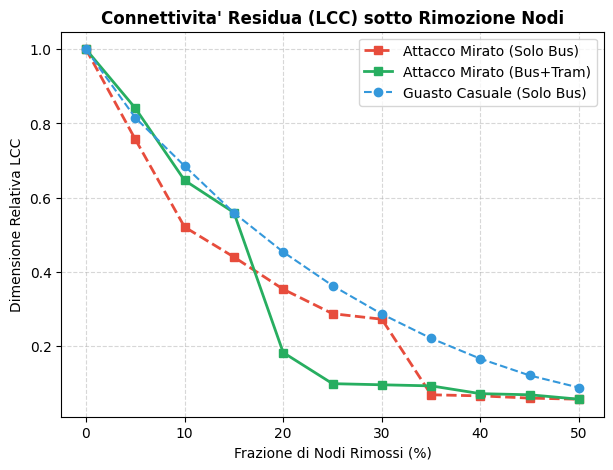

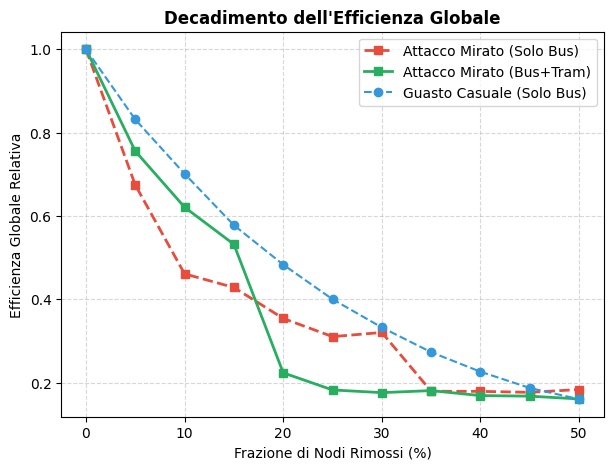

In [3]:
# LCC Plot
plt.figure(figsize=(7, 5))
plt.plot(fracs * 100, t_lcc_bus, 's--', color='#e74c3c', label='Attacco Mirato (Solo Bus)', linewidth=2)
plt.plot(fracs * 100, t_lcc_tram, 's-', color='#27ae60', label='Attacco Mirato (Bus+Tram)', linewidth=2)
plt.plot(fracs * 100, r_lcc_bus, 'o--', color='#3498db', label='Guasto Casuale (Solo Bus)', linewidth=1.5)
plt.xlabel('Frazione di Nodi Rimossi (%)')
plt.ylabel('Dimensione Relativa LCC')
plt.title('Connettivita\' Residua (LCC) sotto Rimozione Nodi', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Efficiency Plot
plt.figure(figsize=(7, 5))
plt.plot(fracs * 100, t_eff_bus, 's--', color='#e74c3c', label='Attacco Mirato (Solo Bus)', linewidth=2)
plt.plot(fracs * 100, t_eff_tram, 's-', color='#27ae60', label='Attacco Mirato (Bus+Tram)', linewidth=2)
plt.plot(fracs * 100, r_eff_bus, 'o--', color='#3498db', label='Guasto Casuale (Solo Bus)', linewidth=1.5)
plt.xlabel('Frazione di Nodi Rimossi (%)')
plt.ylabel('Efficienza Globale Relativa')
plt.title('Decadimento dell\'Efficienza Globale', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()